# Investigation 15: Heatmap Analysis
This notebook centralizes all heatmap analyses for the association rules. It contains the original Rule vs. Stage heatmap, and the Antecedent vs. Consequent heatmap.

## Configuration & Constants
Set your filtering and visualization preferences here. To filter for specific stages, change `STAGES_TO_INCLUDE` from `None` to a list like `['1', '2']`.

In [1]:
# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================
# Data Filtering
RULE_MAX_ITEMS = 2
NO_SELF = True
ORGANS_TO_INCLUDE = None # e.g., ['Colon', 'Duodenum'] or None for all
STAGES_TO_INCLUDE = None # e.g., ['1', '2'] or None for all
SCORE_COLUMN = 'Pathological score' # Options: 'Pathological score', 'Clinical score'

# Paths
RESULT_CSV_PATH = '../../results/full_run/weighted_fpgrowth_4_items_no_markers_with_ex_per/data/'

# Heatmap Settings
TOP_N_RULES = 30
TOP_N_PER_FOV = 5
HEATMAP_CMAP = "YlOrRd"

## Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import ast
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../../'))

## Helper Methods
These methods are used to clean, aggregate, and plot the rules.

In [3]:
def check_rule_overlap(ant_list, con_list):
    ant_clean_list = [item.replace('_CENTER', '').replace('_NEIGHBOR', '') for item in ant_list]
    con_clean_list = [item.replace('_CENTER', '').replace('_NEIGHBOR', '') for item in con_list]
    if len(ant_clean_list) != len(set(ant_clean_list)):
        return True
    if len(con_clean_list) != len(set(con_clean_list)):
        return True
    return not set(ant_clean_list).isdisjoint(set(con_clean_list))

def select_top_n_rules(df_fov_rules, n=5):
    if len(df_fov_rules) <= n:
        return df_fov_rules
        
    pos = df_fov_rules[df_fov_rules["Lift"] >= 1].sort_values("Lift", ascending=False)
    neg = df_fov_rules[df_fov_rules["Lift"] < 1].sort_values("Lift", ascending=True)
    
    n_pos, n_neg = len(pos), len(neg)
    half = n // 2
    
    if n_pos < half:
        take_pos = n_pos
        take_neg = min(n_neg, n - n_pos)
    elif n_neg < half:
        take_neg = n_neg
        take_pos = min(n_pos, n - n_neg)
    else:
        take_pos = half
        take_neg = n - half
        
    return pd.concat([pos.head(take_pos), neg.head(take_neg)]).drop_duplicates()

def clean_items(item_str):
    items = ast.literal_eval(str(item_str))
    return ", ".join(sorted([i.replace('_CENTER', '').replace('_NEIGHBOR', '') for i in items]))

In [4]:
def aggregate_top_rules(df_results, df_metadata, score_col, top_n=5, no_self=True):
    """
    Extracts top N rules per FOV, cleans the names, and aggregates counts by stage.
    """
    results_filtered = df_results.copy()
    if ORGANS_TO_INCLUDE is not None:
        print(f"Filtering for organs: {ORGANS_TO_INCLUDE}")
        df_metadata = df_metadata[df_metadata['Organ'].isin(ORGANS_TO_INCLUDE)]
        results_filtered = df_results[df_results['FOV'].isin(df_metadata['FOV'])].copy()

    # Apply STAGES_TO_INCLUDE filter if present
    if STAGES_TO_INCLUDE is not None:
        print(f"Filtering for stages: {STAGES_TO_INCLUDE}")
        df_metadata = df_metadata[df_metadata[score_col].isin(STAGES_TO_INCLUDE)]
        results_filtered = results_filtered[results_filtered['FOV'].isin(df_metadata['FOV'])].copy()

    top_rules_list = []
    for fov, group in results_filtered.groupby('FOV'):
        top_rules_list.append(select_top_n_rules(group, n=top_n))
    
    if not top_rules_list:
        return pd.DataFrame(), df_metadata, pd.DataFrame()
        
    df_top = pd.concat(top_rules_list, ignore_index=True)
    
    df_top['Clean_Ant'] = df_top['Antecedents'].apply(clean_items)
    df_top['Clean_Con'] = df_top['Consequents'].apply(clean_items)
    
    if no_self:
        mask = df_top.apply(lambda row: check_rule_overlap(row['Clean_Ant'].split(', '), row['Clean_Con'].split(', ')), axis=1)
        df_top = df_top[~mask].copy()

    df_top['Clean_Rule'] = df_top['Clean_Ant'] + " -> " + df_top['Clean_Con']
    
    if score_col in df_top.columns:
        df_top = df_top.drop(columns=[score_col])
    df_merged = df_top.merge(df_metadata[['FOV', score_col]], on='FOV', how='left')
    
    # Count total FOVs per rule
    total_counts = df_merged.groupby('Clean_Rule')['FOV'].nunique().rename('Total FOVs')
    
    # Count FOVs per rule per stage
    stage_counts = df_merged.groupby(['Clean_Rule', score_col])['FOV'].nunique().unstack(fill_value=0)
    
    # Combine and sort
    df_agg = pd.concat([total_counts, stage_counts], axis=1).fillna(0).astype(int)
    df_agg = df_agg.sort_values(by='Total FOVs', ascending=False)
    
    return df_agg, df_metadata, df_top

## Heatmap Methods

In [5]:
def plot_rules_heatmap(df_agg, df_metadata, score_col, max_rules_to_show=30):
    """
    Plots a clean heatmap of the aggregated rule counts vs stages.
    (Migrated directly from Investigation 06)
    """
    if df_agg.empty:
        print("No data to plot.")
        return
        
    df_plot = df_agg.head(max_rules_to_show).copy()
    
    total_fovs = df_metadata['FOV'].nunique()
    stage_totals = df_metadata.groupby(score_col)['FOV'].nunique()
    
    new_columns = {}
    for col in df_plot.columns:
        if col == 'Total FOVs':
            new_columns[col] = f"{col}\n(n={total_fovs})"
        elif col in stage_totals:
            new_columns[col] = f"{col}\n(n={stage_totals[col]})"
        else:
            new_columns[col] = col
    df_plot = df_plot.rename(columns=new_columns)
    
    df_pct = df_plot.copy().astype(float)
    annot_matrix = []
    for idx, row in df_plot.iterrows():
        annot_row = []
        for col_name, val in row.items():
            original_col = [k for k, v in new_columns.items() if v == col_name][0]
            if original_col == 'Total FOVs':
                t = total_fovs
            elif original_col in stage_totals:
                t = stage_totals[original_col]
            else:
                t = val
                
            if t > 0:
                pct = (val / t) * 100
                annot_row.append(f"{val} ({pct:.1f}%)")
                df_pct.at[idx, col_name] = pct
            else:
                annot_row.append(f"{val} (0.0%)")
                df_pct.at[idx, col_name] = 0.0
        annot_matrix.append(annot_row)
        
    plt.figure(figsize=(14, max(6, len(df_plot) * 0.3)))
    sns.heatmap(df_pct, annot=annot_matrix, fmt="", cmap=HEATMAP_CMAP, cbar_kws={'label': 'Percentage of FOVs (%)'})
    
    title_str = f"Top Rules Prevalence across {score_col}"
    if ORGANS_TO_INCLUDE is not None:
        title_str += f" ({', '.join(ORGANS_TO_INCLUDE)})"
    if STAGES_TO_INCLUDE is not None:
        title_str += f" | Filtered by Stages: {', '.join(map(str, STAGES_TO_INCLUDE))}"
        
    plt.title(title_str, fontsize=14, pad=15)
    plt.ylabel("Cleaned Rule", fontsize=12)
    plt.xlabel("Stage", fontsize=12)
    
    plt.tick_params(axis='both', which='major', labelsize=10, top=True, labeltop=True, bottom=False, labelbottom=False)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_ant_cons_heatmap(df_top_rules, df_metadata, max_rules=30):
    """
    Plots an Antecedent (Y) x Consequent (X) heatmap.
    The color and annotations represent the % of FOVs containing the rule in the filtered dataset.
    """
    if df_top_rules.empty:
        print("No rules to plot.")
        return
        
    # Get top rules based on global frequency in df_top_rules
    rule_counts = df_top_rules.groupby('Clean_Rule')['FOV'].nunique().sort_values(ascending=False).head(max_rules)
    top_rules_subset = df_top_rules[df_top_rules['Clean_Rule'].isin(rule_counts.index)]
    
    total_fovs = df_metadata['FOV'].nunique()
    
    # Create a pivot table: index=Clean_Ant, columns=Clean_Con, values=FOV count
    pivot_counts = top_rules_subset.pivot_table(
        index='Clean_Ant', 
        columns='Clean_Con', 
        values='FOV', 
        aggfunc='nunique'
    ).fillna(0)
    
    # Convert counts to percentages
    pivot_pct = (pivot_counts / total_fovs) * 100
    
    # Create annotations array
    annot_matrix = []
    for idx, row in pivot_counts.iterrows():
        annot_row = []
        for col, val in row.items():
            if val > 0:
                pct = (val / total_fovs) * 100
                annot_row.append(f"{int(val)}\n({pct:.1f}%)")
            else:
                annot_row.append("")
        annot_matrix.append(annot_row)
        
    plt.figure(figsize=(12, max(6, len(pivot_counts) * 0.6)))
    ax = sns.heatmap(
        pivot_pct, 
        annot=annot_matrix, 
        fmt="", 
        cmap=HEATMAP_CMAP, 
        cbar_kws={'label': f'Percentage of selected FOVs (n={total_fovs}) (%)'},
        linewidths=.5,
        square=True
    )
    
    # Customize plot
    title_str = "Antecedent x Consequent Rule Prevalence"
    if ORGANS_TO_INCLUDE is not None:
        title_str += f"\nOrgans: {', '.join(ORGANS_TO_INCLUDE)}"
    if STAGES_TO_INCLUDE is not None:
        title_str += f"\nStages: {', '.join(map(str, STAGES_TO_INCLUDE))}"
        
    plt.title(title_str, fontsize=14, pad=15)
    plt.ylabel("Antecedent (Center)", fontsize=12, fontweight='bold')
    plt.xlabel("Consequent (Neighbor)", fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Load Data
Loads FOV metadata and the results files.

In [7]:
def get_data_dir():
    current_dir = os.path.abspath(os.getcwd())
    while current_dir != os.path.dirname(current_dir):
        potential_data = os.path.join(current_dir, 'data', 'MIBIGutCsv')
        if os.path.exists(potential_data):
            return potential_data
        current_dir = os.path.dirname(current_dir)
    return '../../data/MIBIGutCsv' 

data_dir = get_data_dir()
print(f"Loading metadata from: {data_dir}")

df_fovs = pd.read_csv(os.path.join(data_dir, 'fovs_metadata.csv'))
df_biopsy = pd.read_csv(os.path.join(data_dir, 'biopsy_metadata.csv'))

# Merge FOV with Biopsy
df_fovs = pd.merge(
    df_fovs,
    df_biopsy[['Biopsy_ID', 'Pathological score', 'Clinical score', 'Localization']],
    left_on='Patient',
    right_on='Biopsy_ID',
    how='left'
)

def get_organ(row):
    if pd.notna(row.get("Localization")): return row["Localization"]
    cohort = str(row.get("Cohort", ""))
    if "Colon" in cohort: return "Colon"
    if "Duodenum" in cohort: return "Duodenum"
    return "Unknown"

df_fovs["Organ"] = df_fovs.apply(get_organ, axis=1)

def get_clean_score(row, score_col="Pathological score"):
    val = row[score_col]
    if pd.isna(val) or val in ["Unknown", "Not_Applicable", "N/A"]: return "Unknown"
    if isinstance(val, float): return str(int(val))
    return str(val)

df_fovs["Pathological score"] = df_fovs.apply(lambda row: get_clean_score(row, "Pathological score"), axis=1)
df_fovs["Clinical score"] = df_fovs.apply(lambda row: get_clean_score(row, "Clinical score"), axis=1)

print("Loading results data...")
df_results = pd.DataFrame()
if os.path.isdir(RESULT_CSV_PATH):
    dfs = []
    for file in os.listdir(RESULT_CSV_PATH):
        if file.endswith('.csv'):
            dfs.append(pd.read_csv(os.path.join(RESULT_CSV_PATH, file)))
    if dfs:
        df_results = pd.concat(dfs, ignore_index=True)
else:
    if os.path.exists(RESULT_CSV_PATH):
        df_results = pd.read_csv(RESULT_CSV_PATH)

if not df_results.empty:
    df_results['num_items'] = df_results['Antecedents'].apply(lambda x: len(ast.literal_eval(x))) + \
                              df_results['Consequents'].apply(lambda x: len(ast.literal_eval(x)))
    df_results = df_results[df_results['num_items'] <= RULE_MAX_ITEMS]
    
print(f"Loaded {len(df_results)} rules and {len(df_fovs)} FOVs.")

Loading metadata from: c:\Users\Owner\Documents\script-rule-mining\data\MIBIGutCsv
Loading results data...
Loaded 23049 rules and 288 FOVs.


## Process Rules & Plot Heatmaps
This section aggregates the top rules per FOV using the constants defined at the top of the notebook, and then displays the two main heatmaps.

In [8]:
# 1. Aggregate rules based on configuration
df_aggregated, df_fovs_filtered, df_top_rules = aggregate_top_rules(
    df_results, 
    df_fovs, 
    score_col=SCORE_COLUMN, 
    top_n=TOP_N_PER_FOV, 
    no_self=NO_SELF
)

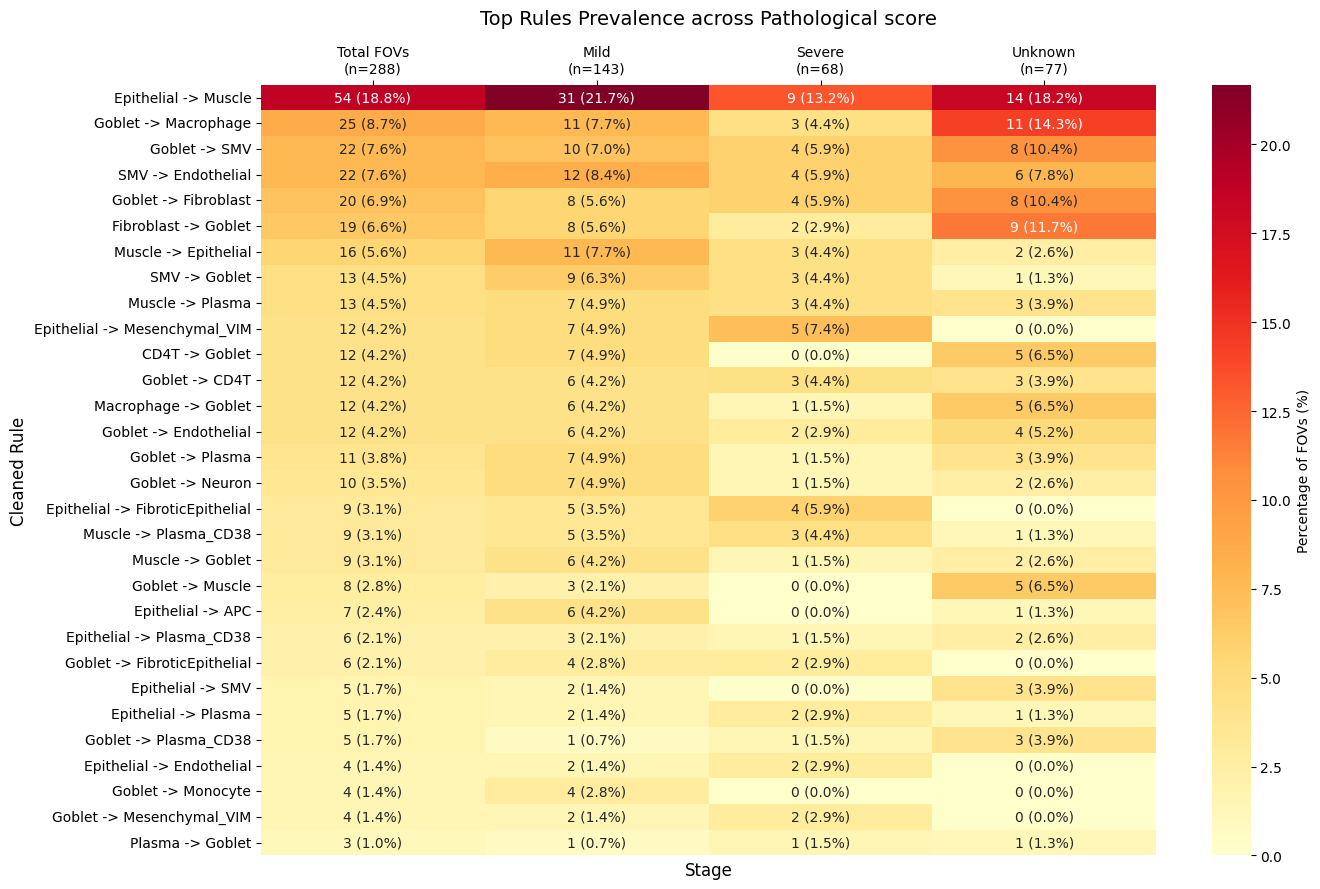

In [9]:
# 2. Plot Original Heatmap (Rule vs Stage)
plot_rules_heatmap(
    df_aggregated, 
    df_fovs_filtered, 
    score_col=SCORE_COLUMN, 
    max_rules_to_show=TOP_N_RULES
)

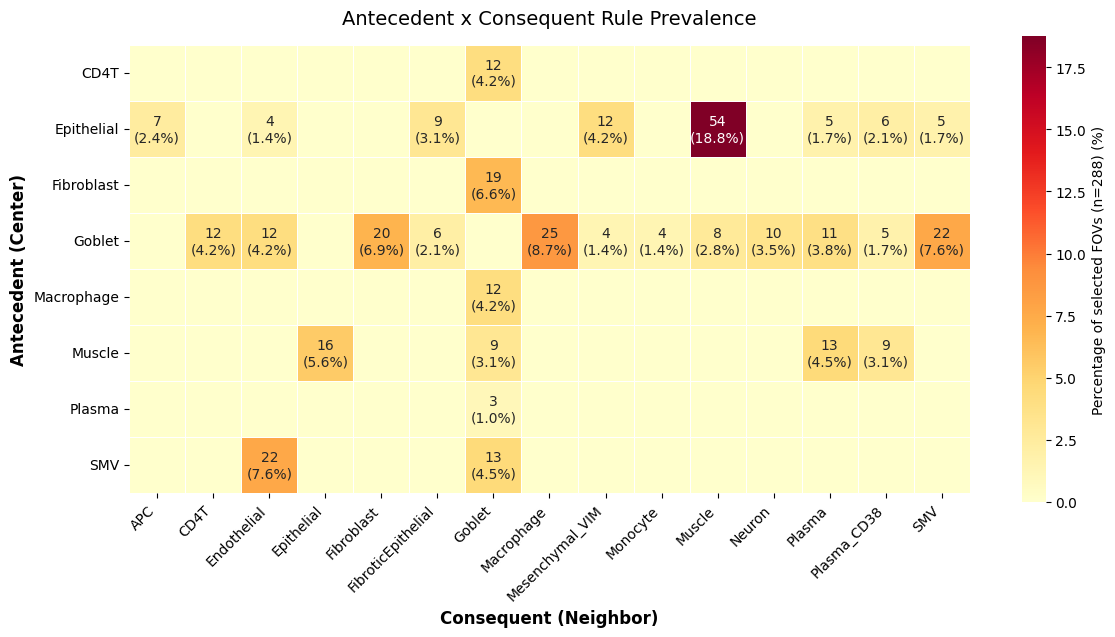

In [10]:
# 3. Plot New Heatmap (Antecedent vs Consequent)
plot_ant_cons_heatmap(
    df_top_rules, 
    df_fovs_filtered, 
    max_rules=TOP_N_RULES
)